In [1]:
#import of the packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os
from sklearn.linear_model import LinearRegression as lr 

#import from package 'geone'
from geone import img
from geone import grf
import geone.imgplot as imgplt
import geone.customcolors as ccol
import geone.deesseinterface as dsi


#read the simulation methods function file
exec(open('../functions/02_simulation_functions.py').read())
exec(open('../functions/02_kriging_functions.py').read())


%matplotlib inline
%xmode Plain

Exception reporting mode: Plain


In [3]:
path_data_test = '../generated_data_withoutTrend/'
path_ti        = '../data/TI/pickle/ti_alt1_2016_2m.pickle'
simu_test_name = os.listdir(path_data_test)[0]
simu_test_name

'realisation0.pickle'

In [6]:
read_data('../data','TI_Alt2_After_Julien1.tif')

ValueError: could not convert string to int

In [4]:
trueMNT, position, hd_df, ti, mask = read_data(path_data_test, simu_test_name)

ValueError: too many values to unpack (expected 5)

In [5]:
t = read_data(path_data_test, simu_test_name)

In [6]:
len(t)

7

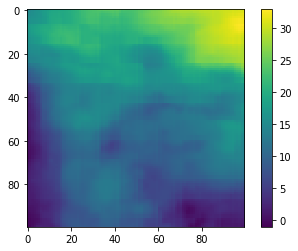

In [9]:
plt.imshow(t[0])
plt.colorbar()

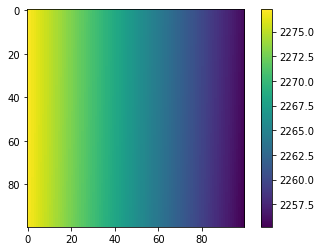

In [12]:
plt.imshow(t[1])
plt.colorbar()

In [13]:
t[2]

array([2621, 2721,  374,  474])

In [14]:
t[3]

,cell_x,cell_y,alt,X,Y
0,2621,439,0.007324,583010.0,136474.0
1,2622,439,0.375488,583010.0,136476.0
2,2623,439,0.805420,583010.0,136478.0
3,2624,439,1.311523,583010.0,136480.0
4,2625,440,1.894775,583012.0,136482.0
...,...,...,...,...,...
667,2720,469,2.642578,583070.0,136672.0
668,2720,470,2.123535,583072.0,136672.0
669,2720,471,1.916992,583074.0,136672.0
670,2720,472,1.593506,583076.0,136672.0


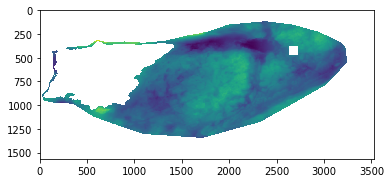

In [16]:
plt.imshow(t[4])

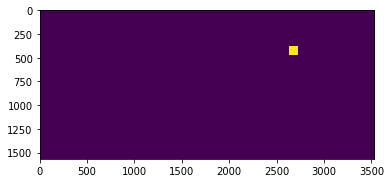

In [17]:
plt.imshow(t[5])

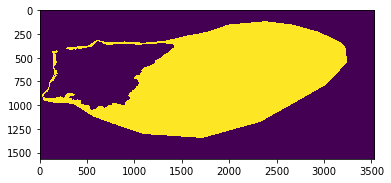

In [18]:
plt.imshow(t[6])

In [20]:
#Set the model:
cov_model = gcm.CovModel2D(elem=[
    ('spherical', {'w':380., 'r':[324,228]}),
    ('gaussian', {'w':90., 'r':[564,564]}),
    ('gaussian', {'w':130., 'r':[1000000,1000]}),
    ('gaussian', {'w':20., 'r':[1000000,1800]}),
    ('spherical', {'w':20., 'r':[1000000,1000]})# elementary contribution
                       ], alpha=20, name='model-2D test')

In [21]:
g#Set the function:
cov_fun = cov_model.func()
vario_fun = cov_model.vario_func()

In [29]:
hd_df = t[3]
position = t[2]
hd_df.head()

,cell_x,cell_y,alt,X,Y
0,2621,439,0.007324,583010.0,136474.0
1,2622,439,0.375488,583010.0,136476.0
2,2623,439,0.805420,583010.0,136478.0
3,2624,439,1.311523,583010.0,136480.0
4,2625,440,1.894775,583012.0,136482.0


In [23]:
help(gcm)

Help on module geone.covModel in geone:

NAME
    geone.covModel

DESCRIPTION
    Python module:  'covModel.py'
    author:         Julien Straubhaar
    date:           jan-2018
    
    Definition of classes for covariance / variogram models in 1D, 2D and 3D.

CLASSES
    builtins.object
        CovModel1D
        CovModel2D
        CovModel3D
    
    class CovModel1D(builtins.object)
     |  Defines a covariance model in 1D:
     |      elem:   (sequence of 2-tuple) an entry (t, d) of the sequence
     |                  corresponds to an elementary model with:
     |                      t: (string) the type, could be
     |                         'nugget', 'spherical', 'exponential', 'gaussian',
     |                         'cubic', 'power'
     |                      d: (dict) dictionary of required parameters to be
     |                          passed to the elementary model,
     |                  e.g.
     |                     (t, d) = ('power', {w:2.0, r:1.5, s:1.7})
